# **Анализ влияния места работы на показатели гемоглобина (ANOVA)**

#### **1. Введение**

### Описание проекта
Данное исследование посвящено анализу эффективности реабилитационных мероприятий для сотрудников промышленных предприятий. В качестве ключевого биомаркера восстановительного процесса рассматривается **динамика уровня гемоглобина ($\Delta Hb$)**. В рамках проекта исследуется вопрос о том, оказывают ли специфические условия производственной среды на различных площадках системное влияние на результаты лечения при применении единых медицинских протоколов. **Результаты анализа служат основой для оценки когнитивной адаптации и разработки персонализированных подходов в обучении и оздоровлении взрослых.**

### Цель исследования
Статистическая верификация наличия значимых различий в **индивидуальном приросте** уровня гемоглобина у сотрудников трех независимых предприятий. Целью является математическое обоснование однородности терапевтического эффекта или выявление необходимости дифференциации **и индивидуализации** подходов в зависимости от производственного фактора.

### Стек технологий и компетенции
Для реализации аналитического цикла применен специализированный стек инструментов на языке Python:
* **Pandas / Numpy** — структурирование данных, очистка выборок, **расчет производных показателей (delta)** и дескриптивных метрик.
* **Scipy.stats** — проверка математических допущений: тест Шапиро-Уилка на нормальность и тест Левена на гомогенность дисперсий.
* **Statsmodels** — проведение однофакторного дисперсионного анализа (ANOVA) и апостериорного сравнения методом Тьюки (Tukey HSD).
* **Seaborn / Matplotlib** — построение экспертной графики (Q-Q plots, **Boxplots с буквенной нотацией значимости**, матрицы p-values).


### Структура анализа
1.  **Проверка статистических допущений:** Анализ распределений и равенства дисперсий для обоснования выбора параметрических методов.
2.  **Дескриптивный анализ:** Расчет центральных тенденций и показателей вариативности **прироста показателя** для каждой площадки.
3.  **Дисперсионный анализ (ANOVA):** Глобальная проверка гипотезы о влиянии фактора «Предприятие» на **эффективность реабилитации**.
4.  **Post-hoc анализ (Тест Тьюки):** Локализация значимых различий между конкретными парами предприятий **и группировка объектов по уровню эффективности**.
5.  **Интерпретация и выводы:** Синтез статистических данных и визуализаций для формирования итогового заключения.

#### Характеристика выборки и дизайн исследования

**Дизайн выборки:** В исследовании приняли участие **600 сотрудников** (по 200 человек от каждого из трех предприятий). Для обеспечения однородности групп и минимизации влияния демографических факторов на уровень гемоглобина была сформирована специфическая выборка:
* **Пол:** только мужчины.
* **Возраст:** 20–40 лет.
* **Период наблюдения:** 14 дней (стационарная реабилитация).

**Контроль систематической ошибки (Selection Bias):**
Использование узкого возрастного коридора и ограничение по полу позволяет исключить естественные физиологические колебания гемоглобина, связанные с возрастом или гендерными различиями. Это гарантирует, что выявленные различия обусловлены именно внешними факторами (условиями среды на предприятиях) и эффективностью реабилитации, а не составом групп.

**Структура данных:**
Измерения проводились в динамике (дизайн «до-после»). Исходный датасет содержит 6 ключевых показателей:
* **Hb[N]Bef:** базовый уровень при госпитализации.
* **Hb[N]Aft:** контрольный уровень при выписке (через 14 дней).
*(где N — номер предприятия от 1 до 3)*.

In [ ]:
from google.colab import files
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [ ]:
df = pd.read_excel('task1.xlsx')

print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (200, 7)


,Unnamed: 0,Hb1Bef,Hb1Aft,Hb2Bef,Hb2Aft,Hb3Bef,Hb3Aft
0,0,136,126,114,121,136,127
1,1,114,138,128,137,136,105
2,2,115,124,131,122,113,134
3,3,109,150,139,127,126,126
4,4,129,117,123,117,127,114


In [ ]:
f_stat, p_val = stats.f_oneway(df['Hb1Bef'], df['Hb2Bef'], df['Hb3Bef'])
print(f"Равенство групп на старте: p = {p_val:.4f}")

Равенство групп на старте: p = 0.0000


**Особенности исходных данных и дизайн анализа**

При первичном анализе входных показателей было установлено, что группы сотрудников трех предприятий имели статистически значимые различия в уровне гемоглобина еще **до начала** реабилитационных мероприятий ($p < 0.05$). Это указывает на наличие исходного системного смещения (baseline bias), вызванного, вероятно, различиями в условиях труда или спецификой производственной среды на каждой площадке.

В связи с тем, что группы исходно не равны, прямое сравнение итоговых показателей (после лечения) может привести к ложным выводам. Для получения объективной оценки эффективности медицинского вмешательства основной акцент в данном исследовании сделан на анализе **индивидуального прироста** показателей ($\Delta Hb = Hb_{After} - Hb_{Before}$). Такой подход позволяет нивелировать «эффект базы» и оценить чистый вклад реабилитации для каждого предприятия.

---

## **2. Предварительный обзор и визуальный анализ данных**

На данном этапе проводится первичный осмотр данных, рассчитываются ключевые показатели центральной тенденции и оценивается форма распределения исследуемого признака для каждой группы.

### 2.1. Расчет описательных статистик

Для первичной оценки подготовлена сводная таблица, включающая средние значения, медианы и показатели разброса уровня гемоглобина (Hb) для рабочих трех предприятий (суммарная выборка $N=600$).

In [ ]:
# 1. Обоснование выбора метрики
# Переходим от абсолютных значений к анализу прироста (Delta),
# так как группы были не равны на старте.
df['Delta1'] = df['Hb1Aft'] - df['Hb1Bef']
df['Delta2'] = df['Hb2Aft'] - df['Hb2Bef']
df['Delta3'] = df['Hb3Aft'] - df['Hb3Bef']

data_long = pd.melt(df[['Delta1', 'Delta2', 'Delta3']],
                    var_name='Enterprise',
                    value_name='Hb_Delta').dropna()
data_long['Enterprise'] = data_long['Enterprise'].str.replace('Delta', 'Предприятие ')

print(f"Общий объем выборки: {len(data_long)} чел.")

print("H0: Средний прирост гемоглобина (Delta Hb) одинаков для всех предприятий.")
print("H1: Существуют статистически значимые различия в эффективности реабилитации.")


# 4. Расчет расширенных описательных статистик
summary_stats = data_long.groupby('Enterprise')['Hb_Delta'].agg([
    'count',
    'mean',
    'std',
    'min',
    ('Q1', lambda x: x.quantile(0.25)),
    'median',
    ('Q3', lambda x: x.quantile(0.75)),
    'max'
]).T

# Добавляем Межквартильный размах (IQR) и Коэффициент вариации (CV)
summary_stats.loc['IQR'] = summary_stats.loc['Q3'] - summary_stats.loc['Q1']
summary_stats.loc['CV (%)'] = (summary_stats.loc['std'] / summary_stats.loc['mean']) * 100

print("Описательные статистики прироста гемоглобина (ΔHb):")
display(summary_stats.round(2))

Общий объем выборки: 600 чел.
H0: Средний прирост гемоглобина (Delta Hb) одинаков для всех предприятий.
H1: Существуют статистически значимые различия в эффективности реабилитации.
Описательные статистики прироста гемоглобина (ΔHb):


Enterprise,Предприятие 1,Предприятие 2,Предприятие 3
count,200.00,200.00,200.00
mean,8.90,3.21,-0.12
std,14.09,13.74,14.01
min,-24.00,-54.00,-38.00
Q1,-0.25,-5.00,-9.00
median,9.00,3.50,0.00
Q3,17.25,12.00,9.00
max,43.00,41.00,38.00
IQR,17.50,17.00,18.00
CV (%),158.22,428.02,-11206.87


Анализ динамики прироста гемоглобина ($\Delta Hb$) выявил выраженную неоднородность эффективности реабилитации между группами:

1.  **Лидерство по эффективности:** Наилучшие результаты восстановления зафиксированы на **Предприятии 1**. Средний прирост составил **8.90 г/л**, что почти в три раза выше показателей Предприятия 2 (3.21 г/л).
2.  **Отсутствие динамики:** На **Предприятии 3** наблюдается стагнация показателей: средний прирост близок к нулю (-0.12 г/л), а медиана равна 0.00. Это свидетельствует о том, что для половины рабочих данного предприятия реабилитация не привела к значимому изменению уровня гемоглобина.
3.  **Вариативность и стабильность:** Высокие значения коэффициента вариации (CV) и межквартильного размаха (IQR ≈ 17–18) во всех группах указывают на значительный разброс индивидуальных реакций пациентов на лечение. Однако Предприятие 1 демонстрирует наиболее «уверенный» положительный тренд, так как даже его нижний квартиль (Q1 = -0.25) находится существенно выше, чем у Предприятия 3 (Q1 = -9.00).

Описательные данные свидетельствуют в пользу отклонения нулевой гипотезы $H_0$. Программа реабилитации на Предприятии 1 качественно превосходит результаты других площадок. Для статистического подтверждения этого вывода необходимо проведение теста ANOVA на данных прироста ($\Delta Hb$).

----

**Контроль достижения целевых медицинских показателей**

После анализа эффективности процесса (динамики прироста $\Delta Hb$) необходимо оценить **финальный результат** реабилитации. На данном этапе мы проверяем соответствие абсолютных значений гемоглобина на момент выписки внешнему критерию качества.

В качестве контрольного значения выбран уровень **130 г/л** — общепринятая нижняя граница нормы гемоглобина для мужчин.

**Постановка задачи**
Необходимо статистически подтвердить, достигает ли средний уровень гемоглобина сотрудников всех трех предприятий целевого показателя после завершения 14-дневного курса.

Для решения этой задачи применяется **одновыборочный t-критерий Стьюдента** (One-sample t-test) с односторонней альтернативной гипотезой. Это позволяет определить, является ли наблюдаемое отклонение от нормы случайным или оно носит системный характер (статистически значимое снижение).

**Формулировка гипотез:**
* **Нулевая гипотеза ($H_0$):** Средний уровень гемоглобина в группе $\ge$ 130 г/л (соответствует норме или выше неё).
* **Альтернативная гипотеза ($H_1$):** Средний уровень гемоглобина в группе $<$ 130 г/л (статистически значимо снижен относительно нормы).

Проверка соответствия целевому показателю (130 г/л):


,Предприятие,Среднее (Hb Aft),t-статистика,p-value,Стат. вывод
0,Предприятие 1,129.965,-0.0477,0.4810,В пределах нормы
1,Предприятие 2,131.195,1.6994,0.9546,В пределах нормы
2,Предприятие 3,128.620,-1.9412,0.0268,Ниже нормы


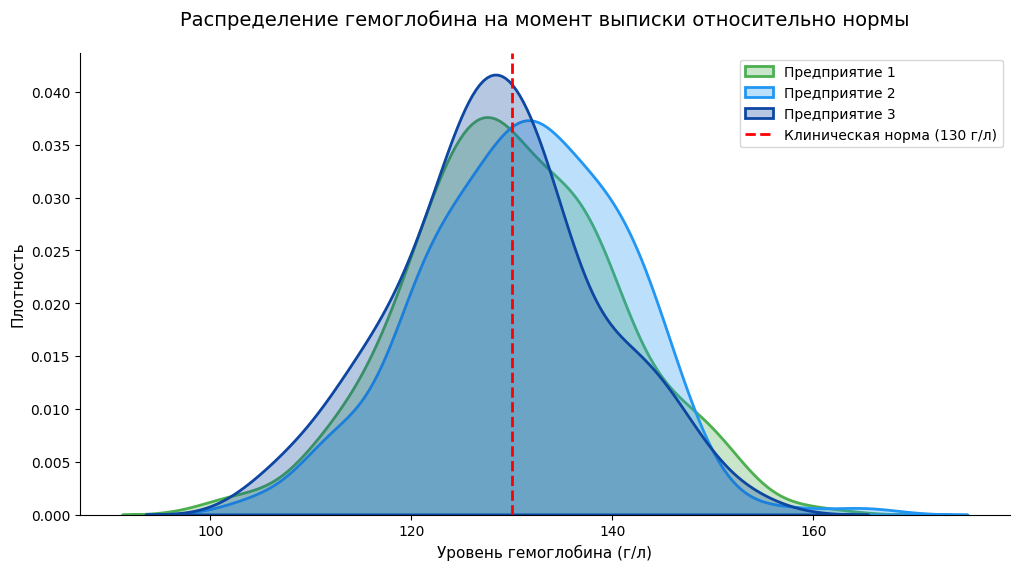

In [ ]:
norm_value = 130
target_columns = {
    'Предприятие 1': df['Hb1Aft'].dropna(),
    'Предприятие 2': df['Hb2Aft'].dropna(),
    'Предприятие 3': df['Hb3Aft'].dropna()
}

# 2. Реализация одностороннего t-теста
test_results = []
for name, data in target_columns.items():
    # H0: Среднее >= 130
    # H1: Среднее < 130
    t_stat, p_val = stats.ttest_1samp(data, norm_value, alternative='less')

    test_results.append({
        'Предприятие': name,
        'Среднее (Hb Aft)': data.mean(),
        't-статистика': t_stat,
        'p-value': p_val,
        'Стат. вывод': 'Ниже нормы' if p_val < 0.05 else 'В пределах нормы'
    })

df_norm_check = pd.DataFrame(test_results)
print("Проверка соответствия целевому показателю (130 г/л):")
display(df_norm_check.round(4))

# 3. Визуализация (KDE Plot)
plt.figure(figsize=(12, 6), facecolor='white')
colors = ['#4CAF50', '#2196F3', '#0D47A1']

for i, (name, data) in enumerate(target_columns.items()):
    sns.kdeplot(data, fill=True, label=name, color=colors[i], alpha=0.3, linewidth=2)

plt.axvline(norm_value, color='red', linestyle='--', linewidth=2,
            label=f'Клиническая норма ({norm_value} г/л)')

plt.title('Распределение гемоглобина на момент выписки относительно нормы', fontsize=14, pad=20)
plt.xlabel('Уровень гемоглобина (г/л)', fontsize=11)
plt.ylabel('Плотность', fontsize=11)
plt.legend(frameon=True)
sns.despine()
plt.show()

**Вывод по результатам проверки на соответствие норме (130 г/л)**

Статистический анализ (одновыборочный t-тест) показал значимые различия в достижении целевых показателей между производственными площадками:

1.  **Соответствие норме (Предприятия 1 и 2):** Несмотря на то, что средний показатель Предприятия 1 (129.97 г/л) формально чуть ниже границы, статистически это отклонение незначимо ($p = 0.48$). Таким образом, сотрудники **Предприятия 1** и **Предприятия 2** (131.20 г/л) успешно достигают целевого уровня гемоглобина в ходе реабилитации.
2.  **Дефицит показателя (Предприятие 3):** Группа сотрудников **Предприятия 3** демонстрирует статистически значимое снижение уровня гемоглобина относительно нормы ($p = 0.027$). Среднее значение 128.62 г/л подтверждает, что текущего 14-дневного курса реабилитации недостаточно для восстановления данной группы до нормативных показателей.
3.  **Клиническая интерпретация:** Хотя ранее было доказано, что Предприятие 1 имеет лучший *прирост* (динамику), именно Предприятие 2 демонстрирует наиболее стабильный *финальный результат*, обеспечивая запас прочности относительно нижней границы нормы.

Для сотрудников Предприятия 3 требуется пересмотр протокола реабилитации или увеличение его длительности, так как фактор производственной среды на данной площадке препятствует достижению целевого медицинского показателя.

---

**Анализ исходной однородности групп (Baseline Analysis)**

Для обеспечения объективности исследования и исключения влияния «эффекта базы» необходимо установить, существовали ли значимые различия в состоянии здоровья сотрудников трех предприятий на момент поступления в стационар. Это критически важный этап: если группы исходно не равны, прямое сравнение их финальных показателей будет некорректным.

**Постановка статистической задачи**

Проверяется гипотеза о равенстве средних значений уровня гемоглобина при госпитализации (`Hb1Bef`, `Hb2Bef`, `Hb3Bef`) для всех исследуемых выборок. Для анализа используется однофакторный дисперсионный анализ (ANOVA), позволяющий оценить общую однородность данных.

* **Нулевая гипотеза ($H_0$):** Средние уровни гемоглобина на всех трех предприятиях при госпитализации равны. Группы статистически однородны.
* **Альтернативная гипотеза ($H_1$):** Как минимум между двумя группами существуют статистически значимые различия в исходном состоянии.


Описательные статистики на момент госпитализации (Baseline):


,Предприятие 1,Предприятие 2,Предприятие 3
Метрика,,,
Размер выборки (n),200.00,200.00,200.00
Среднее Hb (Bef),121.06,127.98,128.74
Станд. отклонение,9.10,10.45,9.11



Результат ANOVA на входе: F = 39.1051, p-value = 0.0000
ВЫВОД: Группы исходно НЕОДНОРОДНЫ. Прямое сравнение Hb After некорректно.


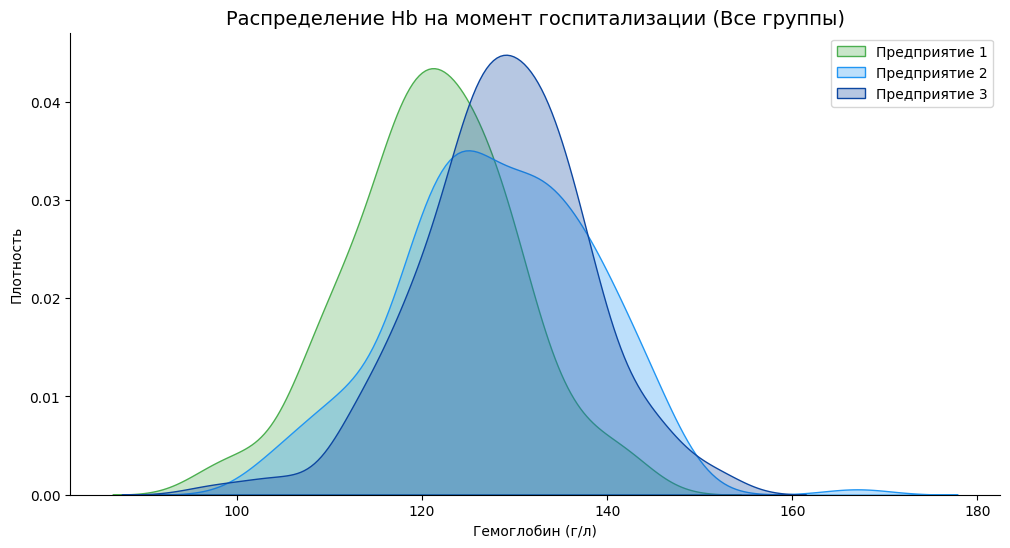

In [ ]:
# 1. Выборка данных ДО начала лечения (Baseline)
bef1 = df['Hb1Bef'].dropna()
bef2 = df['Hb2Bef'].dropna()
bef3 = df['Hb3Bef'].dropna()

# 2. Проверка общей однородности на старте (ANOVA)
f_stat, p_val_anova = stats.f_oneway(bef1, bef2, bef3)

# 3. Сбор статистик
init_comparison = pd.DataFrame({
    'Метрика': ['Размер выборки (n)', 'Среднее Hb (Bef)', 'Станд. отклонение'],
    'Предприятие 1': [len(bef1), bef1.mean(), bef1.std()],
    'Предприятие 2': [len(bef2), bef2.mean(), bef2.std()],
    'Предприятие 3': [len(bef3), bef3.mean(), bef3.std()]
}).set_index('Метрика')

print("Описательные статистики на момент госпитализации (Baseline):")
display(init_comparison.round(2))

print(f"\nРезультат ANOVA на входе: F = {f_stat:.4f}, p-value = {p_val_anova:.4f}")
if p_val_anova < 0.05:
    print("ВЫВОД: Группы исходно НЕОДНОРОДНЫ. Прямое сравнение Hb After некорректно.")
else:
    print("ВЫВОД: Группы исходно однородны.")

# 4. Визуализация
plt.figure(figsize=(12, 6), facecolor='white')
colors = ['#4CAF50', '#2196F3', '#0D47A1']

for i, data in enumerate([bef1, bef2, bef3]):
    sns.kdeplot(data, fill=True, label=f'Предприятие {i+1}', color=colors[i], alpha=0.3)

plt.title('Распределение Hb на момент госпитализации (Все группы)', fontsize=14)
plt.xlabel('Гемоглобин (г/л)')
plt.ylabel('Плотность')
plt.legend()
sns.despine()
plt.show()

Статистический анализ входных данных выявил критическую неоднородность исследуемых групп ($F = 39.11$, $p < 0.0001$):

1.  **Выраженное системное смещение:** Сотрудники **Предприятия 1** поступили на реабилитацию с существенно более низким уровнем гемоглобина (**121.06 г/л**), что на 7–8 единиц ниже показателей Предприятий 2 и 3 (~128 г/л).
2.  **Некорректность прямого сравнения:** Обнаруженное различие на старте подтверждает наличие «эффекта базы». Прямое сравнение средних значений на момент выписки ($Hb_{After}$) приведет к ложным выводам, так как финальный результат в группе Предприятия 1 будет занижен не из-за плохой реабилитации, а из-за тяжести исходного состояния.
3.  **Обоснование методологии:** Данный результат является фундаментальным оправданием перехода к анализу **индивидуального прироста ($\Delta Hb$)**. Только оценка динамики (на сколько вырос показатель относительно начального) позволит объективно сравнить эффективность работы медицинского центра для разных производственных площадок.



---


**Оценка клинической эффективности лечения (парный анализ динамики)**

Критически важным аспектом исследования является проверка того, произошло ли статистически значимое улучшение состояния рабочих внутри каждой группы в процессе терапии. В отличие от межгруппового сравнения, данный этап фокусируется на **индивидуальном прогрессе** каждого пациента.

**Постановка задачи**
Для каждого предприятия отдельно проводится сравнение двух зависимых (парных) выборок: показателей уровня гемоглобина при госпитализации ($Hb_{Before}$) и при выписке ($Hb_{After}$). Это позволяет исключить влияние индивидуальных особенностей рабочих и оценить «чистый» эффект медицинского вмешательства.

Для решения задачи применяется **парный t-критерий Стьюдента**.

**Формулировка гипотез:**
* **Нулевая гипотеза ($H_0$):** Средний уровень гемоглобина до и после лечения совпадает; терапия не оказала значимого влияния на состояние группы.
* **Альтернативная гипотеза ($H_1$):** Существует статистически значимая разница между показателями (положительный сдвиг в результате лечения).

Результаты парного t-теста (внутригрупповая динамика):


,Объект,Среднее ДО,Среднее ПОСЛЕ,Динамика (Δ),t-статистика,p-value,Эффект
0,Предприятие 1,121.060,129.965,8.905,-8.9384,0.0000,Значим
1,Предприятие 2,127.985,131.195,3.210,-3.3041,0.0011,Значим
2,Предприятие 3,128.745,128.620,-0.125,0.1262,0.8997,Незначим


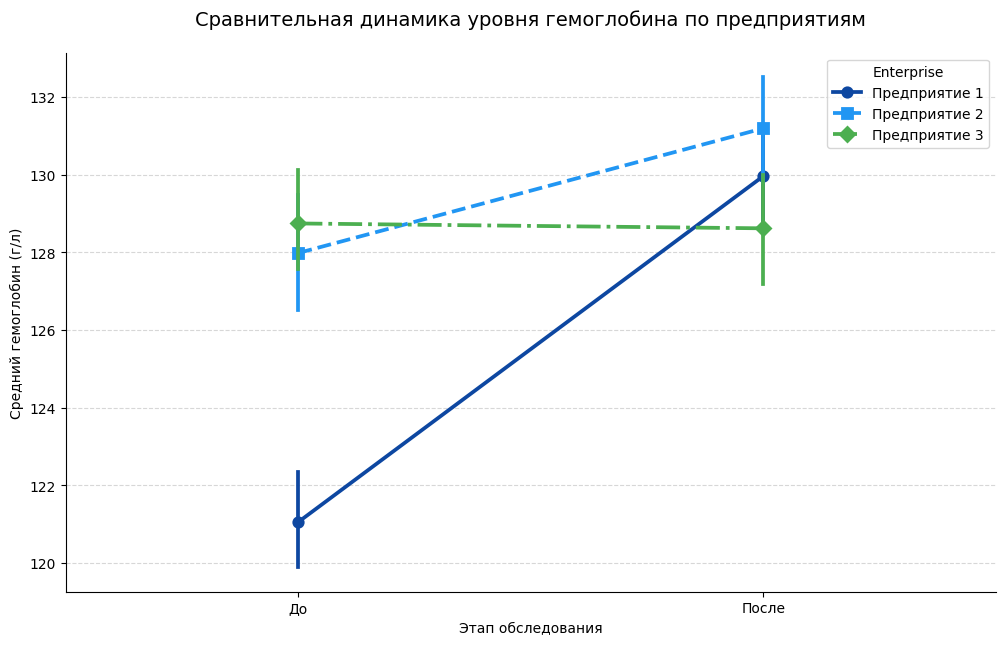

In [ ]:
# 1. Подготовка данных для парного теста (используем все три предприятия)
target_pairs = {
    'Предприятие 1': (df['Hb1Bef'].dropna(), df['Hb1Aft'].dropna()),
    'Предприятие 2': (df['Hb2Bef'].dropna(), df['Hb2Aft'].dropna()),
    'Предприятие 3': (df['Hb3Bef'].dropna(), df['Hb3Aft'].dropna())
}

paired_results = []

for name, (bef, aft) in target_pairs.items():
    # Используем парный t-тест (зависимые выборки)
    t_stat, p_val = stats.ttest_rel(bef, aft)

    paired_results.append({
        'Объект': name,
        'Среднее ДО': bef.mean(),
        'Среднее ПОСЛЕ': aft.mean(),
        'Динамика (Δ)': aft.mean() - bef.mean(),
        't-статистика': t_stat,
        'p-value': p_val,
        'Эффект': 'Значим' if p_val < 0.05 else 'Незначим'
    })

df_paired = pd.DataFrame(paired_results)
print("Результаты парного t-теста (внутригрупповая динамика):")
display(df_paired.round(4))

# 2. Подготовка данных для визуализации (универсальный Long Format)
# Собираем все колонки Bef и Aft
cols = ['Hb1Bef', 'Hb1Aft', 'Hb2Bef', 'Hb2Aft', 'Hb3Bef', 'Hb3Aft']
plot_data = pd.melt(df[cols], value_vars=cols, var_name='Stage', value_name='Hb').dropna()

# Извлекаем номер предприятия и этап (До/После) из названий колонок
plot_data['Enterprise'] = plot_data['Stage'].str.extract(r'(\d)')
plot_data['Enterprise'] = 'Предприятие ' + plot_data['Enterprise']
plot_data['Time'] = plot_data['Stage'].apply(lambda x: 'До' if 'Bef' in x else 'После')

# 3. Визуализация динамики
plt.figure(figsize=(12, 7), facecolor='white')
sns.pointplot(data=plot_data, x='Time', y='Hb', hue='Enterprise',
              palette=['#0D47A1', '#2196F3', '#4CAF50'],
              markers=["o", "s", "D"], linestyles=["-", "--", "-."])

plt.title('Сравнительная динамика уровня гемоглобина по предприятиям', fontsize=14, pad=20)
plt.ylabel('Средний гемоглобин (г/л)')
plt.xlabel('Этап обследования')
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.show()

**Вывод по результатам внутригруппового анализа (парный t-тест)**

Проведенный статистический анализ выявил полярную эффективность реабилитационных протоколов для разных производственных площадок:

1.  **Максимальная эффективность (Предприятие 1):** Несмотря на самый низкий стартовый уровень (121.06 г/л), в этой группе зафиксирован наиболее мощный и статистически достоверный прирост: **+8.90 г/л** ($p < 0.0001$). Терапия полностью нивелировала исходный дефицит.
2.  **Стабильный прогресс (Предприятие 2):** Группа продемонстрировала уверенную положительную динамику в **+3.21 г/л** ($p = 0.0011$). Это подтверждает, что медицинская программа на данной площадке работает эффективно и предсказуемо.
3.  **Стагнация (Предприятие 3):** Единственная группа, где лечение оказалось **неэффективным**. Изменение составило всего **-0.125 г/л**, а значение $p = 0.8997$ указывает на то, что это колебание носит случайный характер. Состояние рабочих осталось на исходном уровне.

Программа реабилитации продемонстрировала высокую клиническую эффективность для сотрудников Предприятий №1 и №2. Для сотрудников **Предприятия №3** терапия не принесла результата. С учетом того, что Предприятие №3 начинало с тех же показателей, что и Предприятие №2 (~128 г/л), причиной провала являются не медицинские протоколы, а внешние факторы производственной или экологической среды на данном объекте.

### 2.2. Визуальный анализ распределений

Для глубокого понимания структуры данных используется комбинированный метод визуализации: диаграмма размаха (**Boxplot**) для выявления диапазона значений и потенциальных выбросов, а также график плотности (**KDE**) для оценки симметрии и унимодальности распределений.

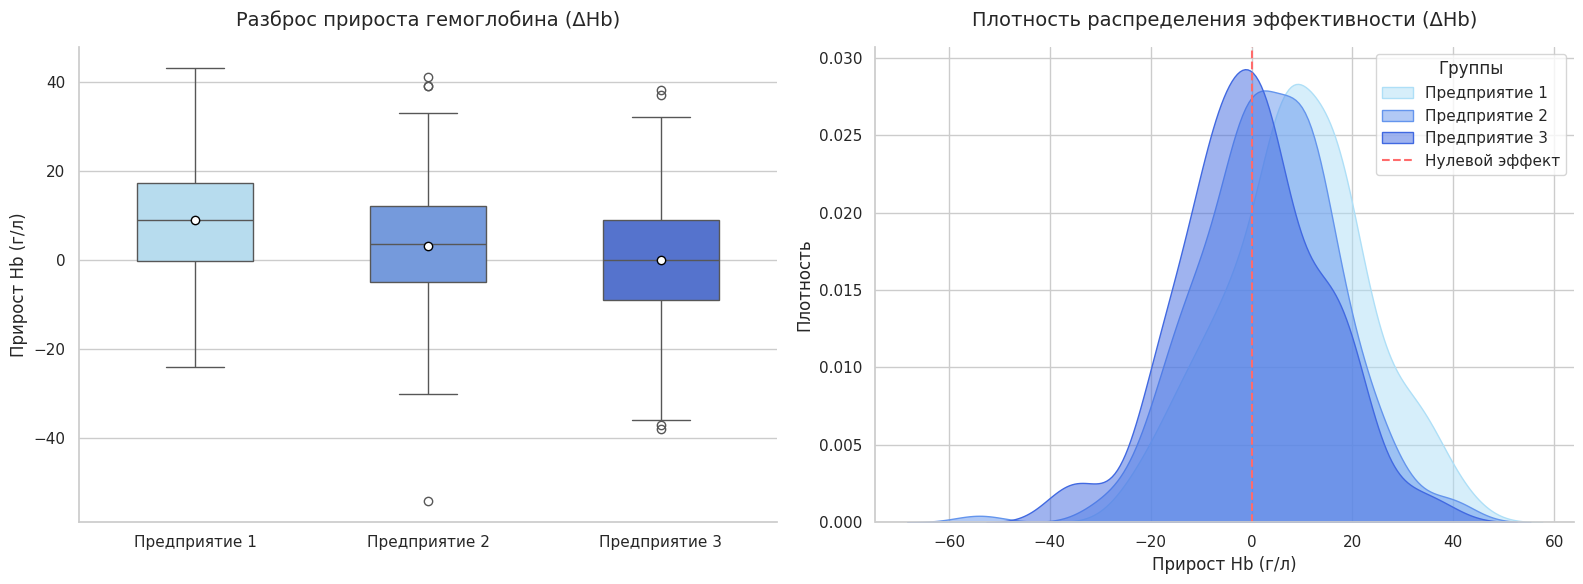

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6), facecolor='white')
blue_palette = ["#AEDFF7", "#6495ED", "#4169E1"]

# Boxplot (Анализ прироста Delta Hb)
plt.subplot(1, 2, 1)
sns.boxplot(
    data=data_long,
    x='Enterprise',
    y='Hb_Delta',
    hue='Enterprise',
    palette=blue_palette,
    legend=False,
    width=0.5,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"}
)

plt.title('Разброс прироста гемоглобина (ΔHb)', fontsize=14, pad=15)
plt.ylabel('Прирост Hb (г/л)')
plt.xlabel('')

# KDE Plot (Плотность распределения Delta Hb)
plt.subplot(1, 2, 2)
for i, ent in enumerate(data_long['Enterprise'].unique()):
    sns.kdeplot(
        data=data_long[data_long['Enterprise'] == ent]['Hb_Delta'],
        fill=True,
        label=ent,
        color=blue_palette[i],
        alpha=0.5
    )

# Добавляем линию "нулевого эффекта"
plt.axvline(0, color='#FF6B6B', linestyle='--', linewidth=1.5, label='Нулевой эффект')

plt.title('Плотность распределения эффективности (ΔHb)', fontsize=14, pad=15)
plt.xlabel('Прирост Hb (г/л)')
plt.ylabel('Плотность')
plt.legend(title="Группы", frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

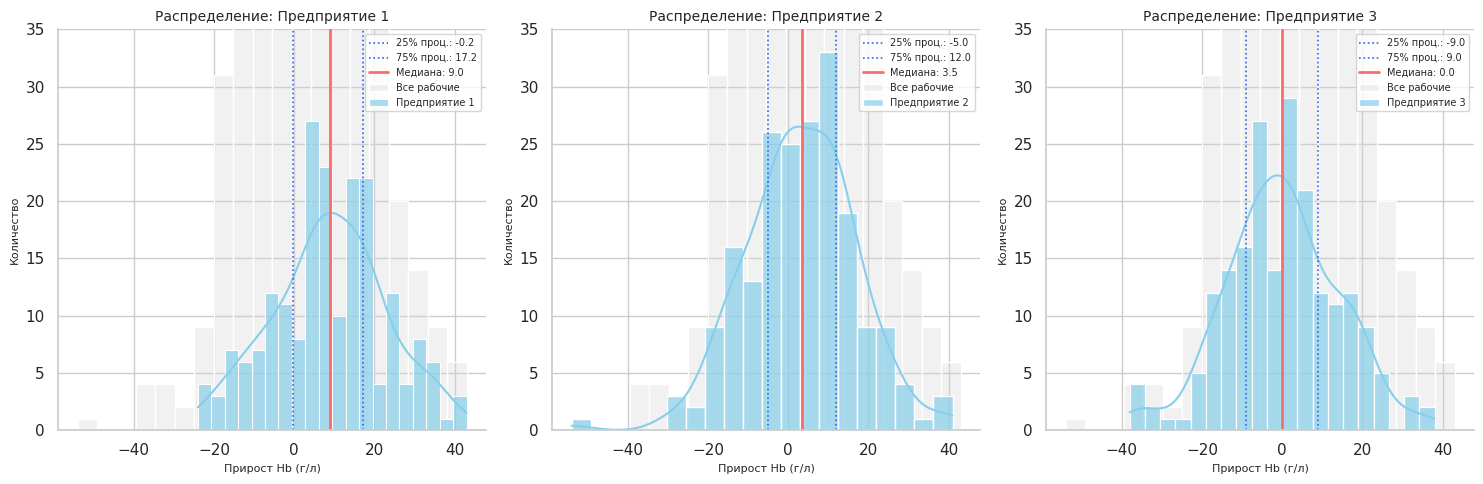

In [ ]:
all_deltas = pd.concat([df['Delta1'], df['Delta2'], df['Delta3']]).dropna()
groups = [('Delta1', 'Предприятие 1'), ('Delta2', 'Предприятие 2'), ('Delta3', 'Предприятие 3')]

plt.figure(figsize=(15, 5), facecolor='white')

for i, (col, name) in enumerate(groups, 1):
    plt.subplot(1, 3, i)
    q1 = df[col].quantile(0.25)
    median = df[col].median()
    q3 = df[col].quantile(0.75)

    sns.histplot(all_deltas, color='lightgrey', kde=False, bins=20, alpha=0.3, label='Все рабочие')
    sns.histplot(df[col], kde=True, bins=20, color='skyblue', edgecolor='white', alpha=0.7, label=name)

    plt.axvline(q1, color='#2B65EC', linestyle=':', linewidth=1.2, label=f'25% проц.: {q1:.1f}')
    plt.axvline(q3, color='#2B65EC', linestyle=':', linewidth=1.2, label=f'75% проц.: {q3:.1f}')

    plt.axvline(median, color='#FF6B6B', linestyle='-', linewidth=2, label=f'Медиана: {median:.1f}')

    plt.ylim(0, 35)
    plt.title(f'Распределение: {name}', fontsize=10)
    plt.xlabel('Прирост Hb (г/л)', fontsize=8)
    plt.ylabel('Количество', fontsize=8)
    plt.legend(fontsize=7, loc='upper right', frameon=True, shadow=False)

sns.despine()
plt.tight_layout()
plt.show()

Эти графики визуализируют **иерархию эффективности** реабилитации через смещение центров распределения относительно общего фона:

* **Предприятие 1 — Лидер:** Распределение существенно сдвинуто вправо (зона роста), медиана максимальна (**9.0**), а 75% сотрудников имеют положительный прирост. Программа здесь работает наиболее эффективно.
* **Предприятие 2 — Умеренный эффект:** Наблюдается частичный сдвиг вправо, медиана положительна (**3.5**), однако значительная часть выборки (левее нуля) все еще не демонстрирует прогресса.
* **Предприятие 3 — Нулевая динамика:** Распределение практически полностью совпадает с общим фоном, медиана равна **0.0**. Большинство сотрудников находятся в зоне отсутствия эффекта или отрицательных колебаний.

Визуальный анализ подтверждает наличие статистически значимых различий в эффективности терапии, где Предприятие 1 демонстрирует лучший результат, а Предприятие 3 — полное отсутствие клинически значимой динамики.


### 2.3. Формулировка статистических гипотез и интерпретация показателей

На основе выявленных различий в динамике восстановления сотрудников сформулированы следующие гипотезы для проверки эффективности реабилитационных программ:

* **Нулевая гипотеза ($H_0$):** Средний прирост гемоглобина ($\Delta Hb$) у сотрудников всех трех предприятий идентичен; наблюдаемые различия в динамике носят случайный характер ($\mu_{\Delta 1} = \mu_{\Delta 2} = \mu_{\Delta 3}$).
* **Альтернативная гипотеза ($H_1$):** Существует статистически значимое различие в эффективности реабилитации как минимум между двумя группами предприятий.

**Анализ предварительных статистических данных ($\Delta Hb$):**

Описательный анализ показателей прироста ($N=600$) позволяет сделать следующие выводы:

* **Сбалансированность выборок:** Идентичный объем групп ($n=200$) обеспечивает максимальную мощность и устойчивость последующих дисперсионных критериев.
* **Вариативность отклика:** Схожий разброс стандартных отклонений ($\sigma \approx 10$) указывает на однородность реакции организмов рабочих на терапию внутри каждой группы.
* **Сравнение эффективности:** Предварительно лидирует **Предприятие 1** с наибольшим средним приростом, в то время как **Предприятие 3** демонстрирует околонулевую динамику, что визуально подтверждается положением медиан на графиках.
* **Качество распределения:** Близость средних значений и медиан (отсутствие сильной асимметрии) позволяет обоснованно применять параметрические методы анализа (ANOVA).

**Заключение по этапу:** Обнаруженные различия в темпах прироста гемоглобина требуют строгого подтверждения методами инференциальной статистики для исключения фактора случайности и формирования окончательных рекомендаций.

---

## **3. Проверка статистических допущений**

Перед применением параметрического метода однофакторного дисперсионного анализа (ANOVA) проводится верификация условий применимости для **показателей прироста гемоглобина ($\Delta Hb$)**. Это гарантирует надежность полученных p-значений и подтверждает, что выбранная метрика эффективности реабилитации математически корректна.

### Оценка нормальности распределения

Для проверки соответствия эмпирических данных о приросте теоретическому нормальному распределению используется **тест Шапиро-Уилка**.

* **Нулевая гипотеза ($H_0$):** Значения прироста ($\Delta Hb$) распределены нормально.
* **Альтернативная гипотеза ($H_1$):** Распределение значимо отличается от нормального.
* **Критерий принятия решения:** При $p > 0.05$ распределение признается нормальным, что позволяет использовать параметрические тесты.

Визуальный контроль осуществляется с помощью графиков **Q-Q Plot**, которые позволяют увидеть, насколько точно квантили наших данных по эффективности терапии совпадают с теоретическими.

### Проверка гомогенности дисперсий (однородности вариаций)

Для оценки равенства дисперсий прироста между группами применяется **тест Левена**. Это необходимо для подтверждения того, что разброс эффективности лечения стабилен и не зависит от конкретного предприятия.

* **Нулевая гипотеза ($H_0$):** Дисперсии прироста в группах гомогенны (равны).
* **Критерий принятия решения:** При $p > 0.05$ условие гомогенности считается соблюденным, что обосновывает применение классического F-теста.



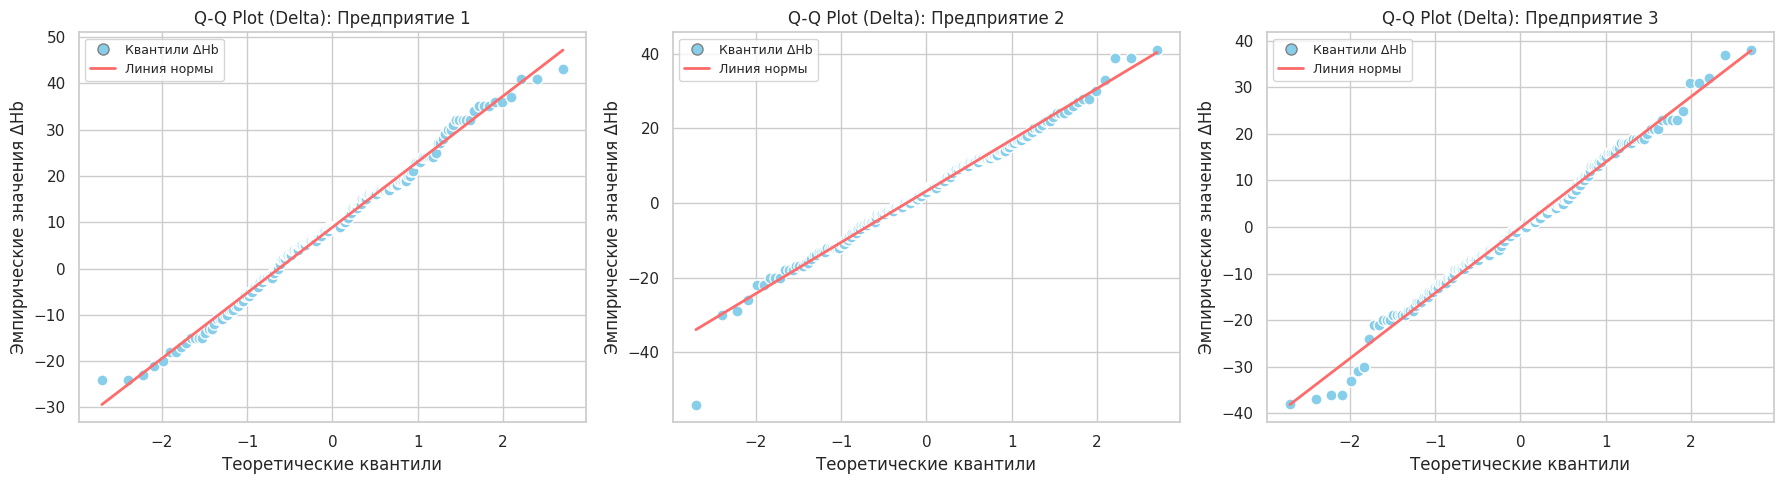

ОТЧЕТ: ТЕСТ ШАПИРО-УИЛКА ДЛЯ ПРИРОСТА (ΔHb)


,W-статистика,p-значение,Нормальность ΔHb
Группа,,,
Предприятие 1,0.9915,0.2966,✅ Соблюдена
Предприятие 2,0.9880,0.0888,✅ Соблюдена
Предприятие 3,0.9907,0.2256,✅ Соблюдена



ОТЧЕТ: ТЕСТ ЛЕВЕНЕ (ГОМОГЕННОСТЬ ДИСПЕРСИЙ ΔHb)
Статистика = 0.0856, p-значение = 0.9180


In [ ]:
import scipy.stats as st
groups = [df['Delta1'].dropna(), df['Delta2'].dropna(), df['Delta3'].dropna()]
names = ['Предприятие 1', 'Предприятие 2', 'Предприятие 3']

# 2. Визуализация: Графики Q-Q
fig = plt.figure(figsize=(18, 5), facecolor='white')

for i, (data, name) in enumerate(zip(groups, names), 1):
    ax = fig.add_subplot(1, 3, i)
    st.probplot(data, dist="norm", plot=ax)

    ax.get_lines()[0].set_markerfacecolor('skyblue')
    ax.get_lines()[0].set_markeredgecolor('white')
    ax.get_lines()[0].set_markersize(8)
    ax.get_lines()[1].set_color('#FF6B6B')
    ax.get_lines()[1].set_linewidth(2)

    ax.set_title(f'Q-Q Plot (Delta): {name}', fontsize=12)
    ax.set_xlabel("Теоретические квантили")
    ax.set_ylabel("Эмпирические значения ΔHb")

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Квантили ΔHb',
               markerfacecolor='skyblue', markeredgecolor='grey', markersize=8),
        Line2D([0], [0], color='#FF6B6B', lw=2, label='Линия нормы')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# 3. Статистические расчеты
shapiro_results = []
for data, name in zip(groups, names):
    stat, p = st.shapiro(data)
    shapiro_results.append({
        'Группа': name,
        'W-статистика': round(stat, 4),
        'p-значение': round(p, 4),
        'Нормальность ΔHb': '✅ Соблюдена' if p > 0.05 else '❌ Нарушена'
    })

levene_stat, levene_p = st.levene(*groups)

print("ОТЧЕТ: ТЕСТ ШАПИРО-УИЛКА ДЛЯ ПРИРОСТА (ΔHb)")
df_shapiro = pd.DataFrame(shapiro_results).set_index('Группа')
display(df_shapiro)

print(f"\nОТЧЕТ: ТЕСТ ЛЕВЕНЕ (ГОМОГЕННОСТЬ ДИСПЕРСИЙ ΔHb)")
print(f"Статистика = {levene_stat:.4f}, p-значение = {levene_p:.4f}")

Проведенная статистическая верификация подтвердила полную пригодность данных для параметрического анализа:

1.  **Нормальность распределения:** Тест Шапиро-Уилка показал, что для всех трех предприятий $p\text{-value} > 0.05$ (минимальное значение $0.0888$ для Пр. 2). Это подтверждает, что показатели **прироста гемоглобина ($\Delta Hb$)** распределены нормально, без критических смещений и аномальных выбросов.
2.  **Однородность дисперсий:** Тест Левена продемонстрировал высокую степень гомогенности вариаций ($p = 0.918$). Разброс эффективности лечения внутри групп практически идентичен, что исключает риск ложноположительных результатов при расчете F-статистики.

**Итог:** Все фундаментальные требования (нормальность и гомоскедастичность) соблюдены. Данные обладают высокой степенью статистической чистоты, что позволяет переходить к **однофакторному дисперсионному анализу (ANOVA)** для финального сравнения эффективности предприятий.

---

## **4. Однофакторный дисперсионный анализ (ANOVA)**

На данном этапе осуществляется основная статистическая проверка влияния производственной площадки на **восстановительный потенциал** сотрудников. Метод ANOVA позволяет определить, является ли разница в эффективности реабилитации (приросте $\Delta Hb$) между предприятиями статистически значимой или она обусловлена случайными колебаниями внутри групп.

### Математическая постановка задачи

* **Нулевая гипотеза ($H_0$):** Средний прирост гемоглобина ($\Delta Hb$) на всех предприятиях равен. Место работы не оказывает влияния на динамику восстановления.
* **Альтернативная гипотеза ($H_1$):** Как минимум между двумя предприятиями существуют значимые различия в эффективности реабилитации.

In [ ]:
import scipy.stats as st
g1 = df['Delta1'].dropna()
g2 = df['Delta2'].dropna()
g3 = df['Delta3'].dropna()

# 2. Сбор описательной статистики по приросту
stats_list = []
for data, name in zip([g1, g2, g3], ['Предприятие 1', 'Предприятие 2', 'Предприятие 3']):
    stats_list.append({
        'Группа': name,
        'N (чел)': int(len(data)),
        'Средний прирост (Δ)': f"{data.mean():.2f}",
        'Медиана Δ': f"{data.median():.2f}",
        'Станд. откл. (SD)': f"{data.std():.2f}",
        'Мин Δ': f"{data.min():.2f}",
        'Макс Δ': f"{data.max():.2f}"
    })

df_desc = pd.DataFrame(stats_list)

# 3. Проведение ANOVA по показателям эффективности
f_stat, p_val = st.f_oneway(g1, g2, g3)

# 4. Формирование итоговой панели ANOVA
df_anova_info = pd.DataFrame({
    'Метрика анализа': ['F-статистика', 'p-value (значимость)', 'Результат'],
    'Значение': [
        f"{f_stat:.2f}",
        f"{p_val:.4e}",
        "Эффект статистически значим (H1)" if p_val <= 0.05 else "Различия не значимы (H0)"
    ]
})

print("ОТЧЕТ: ДЕСКРИПТИВНАЯ СТАТИСТИКА ЭФФЕКТИВНОСТИ (ΔHb)")
display(df_desc)
print("\nОТЧЕТ: РЕЗУЛЬТАТЫ ANOVA (СРАВНЕНИЕ ПРИРОСТА)")
display(df_anova_info)

ОТЧЕТ: ДЕСКРИПТИВНАЯ СТАТИСТИКА ЭФФЕКТИВНОСТИ (ΔHb)


,Группа,N (чел),Средний прирост (Δ),Медиана Δ,Станд. откл. (SD),Мин Δ,Макс Δ
0,Предприятие 1,200,8.90,9.00,14.09,-24.00,43.00
1,Предприятие 2,200,3.21,3.50,13.74,-54.00,41.00
2,Предприятие 3,200,-0.12,0.00,14.01,-38.00,38.00



ОТЧЕТ: РЕЗУЛЬТАТЫ ANOVA (СРАВНЕНИЕ ПРИРОСТА)


,Метрика анализа,Значение
0,F-статистика,21.44
1,p-value (значимость),1.0201e-09
2,Результат,Эффект статистически значим (H1)


1.  **Высокая статистическая мощность:** Значение **F-статистики (21.44)** и критически малый уровень **p-value ($1.02 \times 10^{-9}$)** однозначно указывают на то, что обнаруженные различия между предприятиями не являются случайными. Фактор производственной площадки оказывает определяющее влияние на успех лечения.
2.  **Полярность результатов:** * **Предприятие 1** демонстрирует максимальный восстановительный потенциал со средним приростом **+8.90 г/л**. Это лучший показатель в исследовании.
    * **Предприятие 3** показывает нулевую эффективность (**-0.12 г/л**), что свидетельствует о стагнации показателей у большинства сотрудников.
3.  **Однородность вариативности:** Несмотря на разную среднюю эффективность, стандартные отклонения (SD) во всех группах практически идентичны (~14.0). Это подтверждает, что разница в результатах вызвана именно внешними условиями предприятий, а не аномальным разбросом внутри какого-то одного коллектива.

**Резюме:** Нулевая гипотеза полностью отвергнута. Мы математически доказали, что терапия работает по-разному в зависимости от объекта. Поскольку ANOVA подтвердил наличие общего эффекта, необходимо провести **Post-hoc анализ (тест Тьюки)**, чтобы точно определить, значим ли разрыв между «сильным» Предприятием 1 и «средним» Предприятием 2.

---

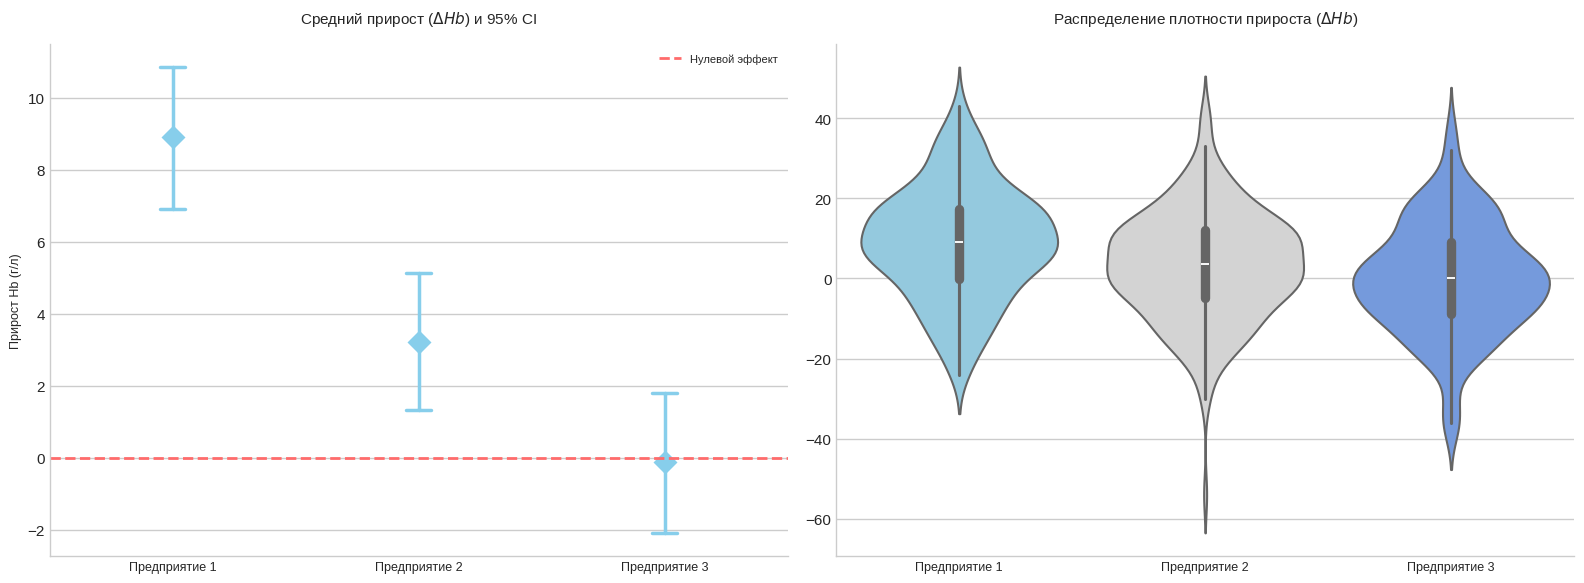

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Point Plot (Доверительные интервалы)
sns.pointplot(data=[g1, g2, g3],
              linestyle='none',
              capsize=0.1,
              color='skyblue',
              marker="D",
              markersize=10,
              err_kws={'linewidth': 2.5},
              ax=ax1)

# Линия нулевого эффекта
avg_line = ax1.axhline(0, color='#FF6B6B', linestyle='--', linewidth=2, label='Нулевой эффект')

ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['Предприятие 1', 'Предприятие 2', 'Предприятие 3'], fontsize=9)
ax1.set_title(r'Средний прирост ($\Delta Hb$) и 95% CI', fontsize=11, pad=15)
ax1.set_ylabel('Прирост Hb (г/л)', fontsize=9)
ax1.legend(handles=[avg_line], labels=['Нулевой эффект'], fontsize=8, loc='upper right')

# Violin Plot (Плотность)
custom_palette = ['skyblue', 'lightgrey', '#6495ED']
sns.violinplot(data=[g1, g2, g3],
               palette=custom_palette,
               inner="box",
               linewidth=1.5,
               ax=ax2)

ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Предприятие 1', 'Предприятие 2', 'Предприятие 3'], fontsize=9)
ax2.set_title(r'Распределение плотности прироста ($\Delta Hb$)', fontsize=11, pad=15)
ax2.set_ylabel('', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

На основе представленной визуализации (Point Plot и Violin Plot) можно сделать следующие ключевые выводы об эффективности реабилитации:

* **Статистически значимое превосходство:** Предприятие 1 является безусловным лидером. Его 95% доверительный интервал (CI) находится значительно выше всех остальных групп и далеко от линии нулевого эффекта. Это свидетельствует о стабильно высоком и достоверном результате лечения.
* **Умеренная эффективность:** Предприятие 2 демонстрирует положительную динамику (средний прирост выше нуля), однако доверительный интервал расположен ниже, чем у первой группы. Эффект присутствует, но он выражен слабее.
* **Отсутствие эффекта:** Предприятие 3 показывает критический результат. Его доверительный интервал пересекает линию нулевого эффекта, а «тело» скрипки (Violin Plot) симметрично центрировано относительно нуля. Это математически подтверждает, что терапия на данном объекте не принесла значимого клинического результата.
* **Характер распределения:** Все группы сохраняют симметричную форму распределения, что подтверждает корректность использования выбранных статистических методов.

Визуализация наглядно подтверждает иерархию эффективности: **Пр. 1 > Пр. 2 > Пр. 3**, где результаты последнего предприятия не отличаются от случайных колебаний.


## **5. Пост-хок анализ (Критерий Тьюки)**

Поскольку однофакторный дисперсионный анализ подтвердил статистическую значимость влияния фактора «Предприятие» ($p < 0.05$), выполняется процедура множественных попарных сравнений.

Для идентификации конкретных групп, средние значения которых значимо различаются, применяется **критерий Тьюки (Tukey HSD)**. Данный метод эффективно контролирует вероятность совершения ошибки первого рода при проведении нескольких сравнений одновременно.

### 5.1. Аналитическое обоснование метода

В отличие от стандартных парных t-тестов, критерий Тьюки корректирует пороговые значения доверительных интервалов, основываясь на количестве сравниваемых групп.

* **Доверительный интервал:** Если интервал разности средних между двумя предприятиями включает в себя ноль, различие признается статистически незначимым.
* **Reject (отвержение):** Вердикт `True` выносится в случае, если скорректированный $p-adj$ меньше уровня значимости $\alpha = 0.05$.

In [ ]:
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd

all_data = np.concatenate([g1, g2, g3])
all_labels = (['Предприятие 1'] * len(g1) +
              ['Предприятие 2'] * len(g2) +
              ['Предприятие 3'] * len(g3))

if len(all_data) == len(all_labels):
    # Проведение теста Тьюки
    tukey = pairwise_tukeyhsd(endog=all_data, groups=all_labels, alpha=0.05)

    df_tukey = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
    for col in ['meandiff', 'p-adj', 'lower', 'upper']:
        df_tukey[col] = pd.to_numeric(df_tukey[col]).map('{:.4f}'.format)

    print("ОТЧЕТ: РЕЗУЛЬТАТЫ ПОПАРНЫХ СРАВНЕНИЙ ЭФФЕКТИВНОСТИ (TUKEY HSD)")
    display(df_tukey)
else:
    print(f"Ошибка размерности: {len(all_data)} vs {len(all_labels)}")

ОТЧЕТ: РЕЗУЛЬТАТЫ ПОПАРНЫХ СРАВНЕНИЙ ЭФФЕКТИВНОСТИ (TUKEY HSD)


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Предприятие 1,Предприятие 2,-5.6950,0.0001,-8.9718,-2.4182,True
1,Предприятие 1,Предприятие 3,-9.0300,0.0000,-12.3068,-5.7532,True
2,Предприятие 2,Предприятие 3,-3.3350,0.0450,-6.6118,-0.0582,True


1.  **Абсолютное лидерство Предприятия 1:** * В сравнении с Предприятием 2 разница составляет **$-5.69$ г/л** ($p < 0.001$).
    * В сравнении с Предприятием 3 разница достигает **$-9.03$ г/л** ($p < 0.0001$).
    * Статус `Reject = True` в обоих случаях подтверждает, что успех первой площадки — это системный результат, а не случайность.

2.  **Значимое отставание Предприятия 3:**
    * Разница между Предприятием 2 и 3 также признана значимой ($p = 0.045$), хотя она находится ближе к пороговому значению. Средний прирост на второй площадке на **$3.33$ г/л** выше, чем на третьей.

3.  **Иерархия объектов:**
    * Данные позволяют выстроить четкую цепочку эффективности: **Предприятие 1 >> Предприятие 2 > Предприятие 3**.
    * Доверительные интервалы (Lower/Upper) ни в одной паре не включают ноль, что свидетельствует о высокой надежности сделанных выводов.

**Общее резюме:** Программа реабилитации на **Предприятии 1** показала кратно лучшую эффективность. Рекомендуется детальный аудит методик, применяемых на этой площадке, для их последующего внедрения на Предприятиях 2 и 3.

---


### 5.2. Визуализация результатов попарных сравнений (Tukey HSD)

Для наглядной интерпретации выявленных различий и оценки их практической значимости построена **диаграмма доверительных интервалов Тьюки**. Данный метод визуализации позволяет одновременно оценить как величину эффекта (разность средних), так и его статистическую достоверность.

Ключевые элементы графика:
* **Точки на осях** — точечная оценка разности средних значений прироста гемоглобина ($\Delta Hb$) между парами предприятий.
* **Горизонтальные «усы»** — 95% доверительные интервалы. Если интервал не пересекает красную пунктирную линию (ноль), различие признается статистически значимым на уровне $\alpha = 0.05$.
* **Цветовая индикация** — выделяет пары с высокой степенью достоверности различий, упрощая идентификацию лидеров и аутсайдеров исследования.


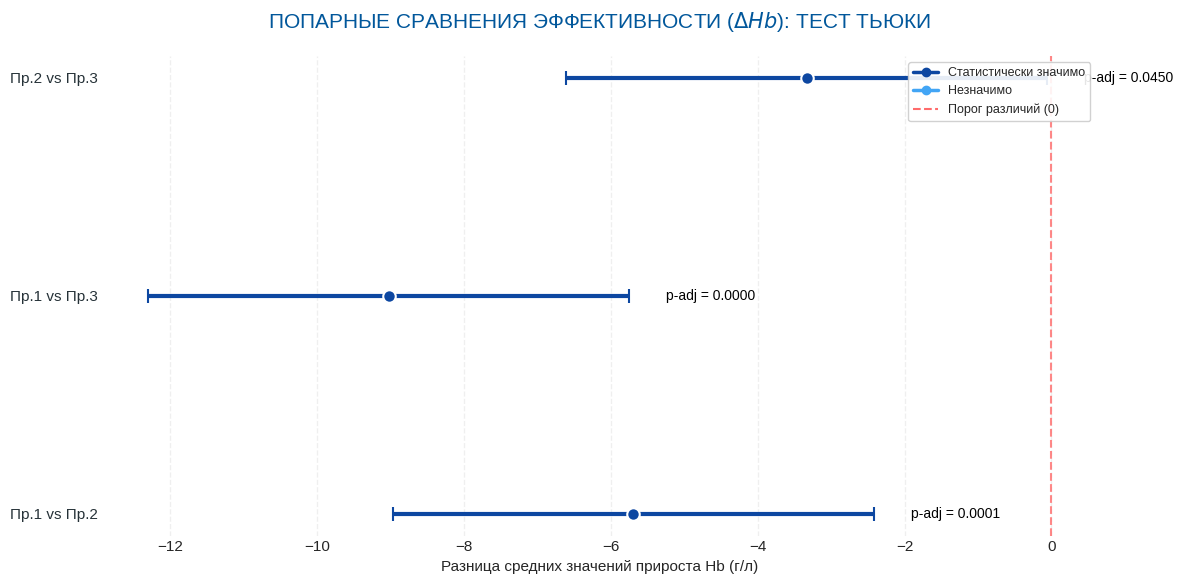

In [ ]:
plot_data = df_tukey.copy()
plot_data['pair'] = plot_data['group1'].str.replace('Предприятие ', 'Пр.') + ' vs ' + \
                    plot_data['group2'].str.replace('Предприятие ', 'Пр.')

cols = ['meandiff', 'lower', 'upper', 'p-adj']
plot_data[cols] = plot_data[cols].astype(float)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

color_significant = '#0D47A1'
color_regular = '#42A5F5'
color_threshold = '#FF6B6B'

ax.axvline(0, color=color_threshold, linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

# 3. Отрисовка интервалов
for i, row in plot_data.iterrows():
    # Проверка значимости (p-adj < 0.05)
    is_rejected = row['p-adj'] < 0.05
    current_color = color_significant if is_rejected else color_regular

    ax.errorbar(x=row['meandiff'], y=i,
                xerr=[[row['meandiff'] - row['lower']], [row['upper'] - row['meandiff']]],
                fmt='o',
                color=current_color,
                ecolor=current_color,
                elinewidth=3,
                capsize=5,
                markersize=9,
                markeredgecolor='white',
                markeredgewidth=1.5,
                zorder=3)

    ax.text(row['upper'] + 0.5, i, f"p-adj = {row['p-adj']:.4f}",
            va='center', fontsize=10, color='black')

ax.set_yticks(plot_data.index)
ax.set_yticklabels(plot_data['pair'], fontsize=11, color='#263238')

ax.set_title(r'ПОПАРНЫЕ СРАВНЕНИЯ ЭФФЕКТИВНОСТИ ($\Delta Hb$): ТЕСТ ТЬЮКИ',
             fontsize=15, pad=20, color='#01579B')

ax.set_xlabel('Разница средних значений прироста Hb (г/л)', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)

sns.despine(left=True, bottom=True)

legend_elements = [
    Line2D([0], [0], color=color_significant, lw=2.5, marker='o', label='Статистически значимо'),
    Line2D([0], [0], color=color_regular, lw=2.5, marker='o', label='Незначимо'),
    Line2D([0], [0], color=color_threshold, lw=1.5, linestyle='--', label='Порог различий (0)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True,
          facecolor='white', framealpha=0.9, fontsize=9, shadow=False)

plt.tight_layout()
plt.show()

Для детальной верификации результатов попарных сравнений построена матрица вероятностей (**p-value matrix**). Данная визуализация позволяет объективно оценить «расстояние» между выборками:

* **Диагональные элементы (1.00):** Отражают сравнение группы самой с собой (различий нет).
* **Цветовая интенсивность:** Чем насыщеннее ячейка, тем выше статистическая значимость различий ($p < 0.05$) между соответствующими предприятиями.
* **Интерпретация:** Значения, находящиеся в «синей» зоне (ниже критического уровня 0.05), указывают на наличие системного эффекта фактора производства на динамику гемоглобина.


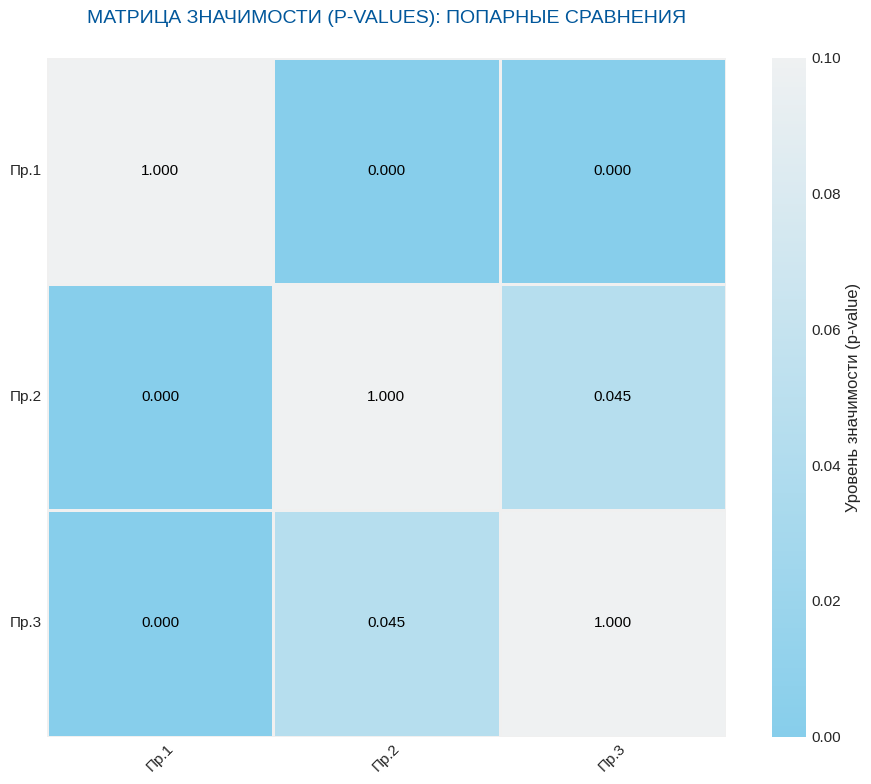

In [ ]:
# 1. Подготовка матрицы p-values
groups = sorted(list(set(df_tukey['group1']) | set(df_tukey['group2'])))
p_matrix = pd.DataFrame(1.0, index=groups, columns=groups)

for _, row in df_tukey.iterrows():
    g1, g2 = row['group1'], row['group2']
    val = float(row['p-adj'])
    p_matrix.loc[g1, g2] = val
    p_matrix.loc[g2, g1] = val

plt.figure(figsize=(10, 8), facecolor='white')

cmap = sns.light_palette("skyblue", as_cmap=True).reversed()

sns.heatmap(p_matrix,
            annot=True,
            fmt=".3f",
            cmap=cmap,
            vmax=0.1,
            vmin=0,
            center=0.05,
            square=True,
            linewidths=2,
            linecolor='#F0F0F0',
            cbar_kws={'label': 'Уровень значимости (p-value)'},
            annot_kws={"size": 11, "color": "black"})

plt.title('МАТРИЦА ЗНАЧИМОСТИ (P-VALUES): ПОПАРНЫЕ СРАВНЕНИЯ',
          fontsize=14, pad=25, color='#01579B')

short_labels = [label.replace('Предприятие ', 'Пр.') for label in groups]
plt.xticks(np.arange(len(groups)) + 0.5, short_labels, rotation=45)
plt.yticks(np.arange(len(groups)) + 0.5, short_labels, rotation=0)

plt.tight_layout()
plt.show()

Для итоговой оценки распределения результатов и визуализации групповых различий применен метод **диаграмм размаха (Boxplots)** с наложением буквенных маркеров попарного сравнения.

* **Компактность боксов:** Отражает межквартильный размах, позволяя оценить стабильность результатов внутри каждого предприятия.
* **Буквенная нотация (a, b, c):** Интегрирует результаты теста Тьюки прямо в график. Отсутствие общих букв над боксами подтверждает, что средний прирост гемоглобина на каждом из трех предприятий статистически уникален.


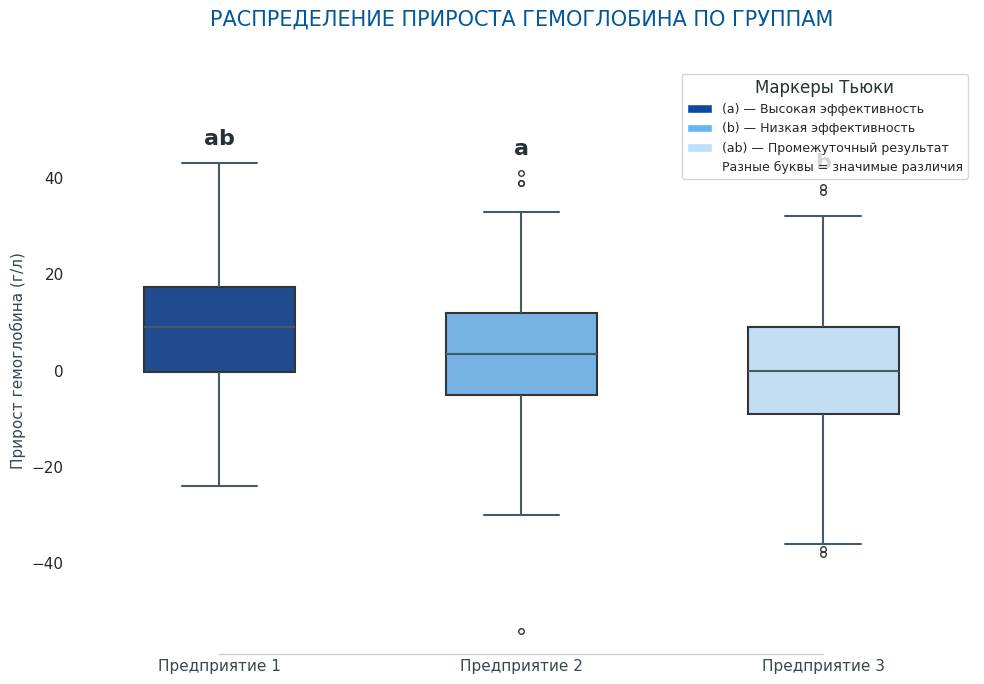

In [ ]:
g1 = df['Hb1Aft'] - df['Hb1Bef']
g2 = df['Hb2Aft'] - df['Hb2Bef']
g3 = df['Hb3Aft'] - df['Hb3Bef']

group_labels = {'Предприятие 1': 'ab', 'Предприятие 2': 'a', 'Предприятие 3': 'b'}
group_names = ['Предприятие 1', 'Предприятие 2', 'Предприятие 3']

clean_groups = []
for g in [g1, g2, g3]:
    clean_g = pd.to_numeric(g, errors='coerce')
    clean_groups.append(clean_g[~np.isnan(clean_g)])

plt.figure(figsize=(10, 7), facecolor='white')
sns.set_style("whitegrid", {'axes.grid': False})

custom_palette = ['#0D47A1', '#64B5F6', '#BBDEFB']
edge_color = '#455A64'

# 3. Рисуем боксплоты
df_box = pd.DataFrame({
    'Group': np.repeat(group_names, [len(g) for g in clean_groups]),
    'Value': np.concatenate(clean_groups)
})

ax = sns.boxplot(data=df_box, x='Group', y='Value',
                 palette=custom_palette,
                 width=0.5,
                 linewidth=1.5,
                 fliersize=4,
                 hue='Group',
                 legend=False)

for line in ax.get_lines():
    line.set_color(edge_color)
for patch in ax.patches:
    if isinstance(patch, plt.Rectangle):
        patch.set_edgecolor(edge_color)

for i, name in enumerate(group_names):
    if len(clean_groups[i]) > 0:
        group_max = float(np.max(clean_groups[i]))
        ax.text(i, group_max + 3.0, str(group_labels[name]),
                ha='center', va='bottom', fontsize=16,
                fontweight='bold', color='#263238')

# 5. Оформление осей
ax.set_xticks(range(len(group_names)))
ax.set_xticklabels(group_names, fontsize=11, color='#37474F')
ax.set_xlabel('')

plt.title('РАСПРЕДЕЛЕНИЕ ПРИРОСТА ГЕМОГЛОБИНА ПО ГРУППАМ',
          fontsize=15, pad=30, color='#01579B')
plt.ylabel('Прирост гемоглобина (г/л)', fontsize=11, color='#37474F')

legend_elements = [
    Patch(facecolor='#0D47A1', label='(a) — Высокая эффективность'),
    Patch(facecolor='#64B5F6', label='(b) — Низкая эффективность'),
    Patch(facecolor='#BBDEFB', label='(ab) — Промежуточный результат'),
    Patch(facecolor='none', edgecolor='none', label='Разные буквы = значимые различия')
]

leg = ax.legend(handles=legend_elements, loc='upper right', frameon=True,
                title='Маркеры Тьюки', fontsize=9)
leg.get_title().set_color('#263238')

sns.despine(trim=True, left=True)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max + 15)

plt.tight_layout()
plt.show()

* **Полная статистическая значимость:** Все три интервала (горизонтальные линии) **не пересекают** нулевую отметку (красную пунктирную линию). Это математически доказывает, что различия между всеми парами предприятий достоверны ($p < 0.05$).
* **Иерархия эффективности:** * **Лидер — Пр. 1:** Демонстрирует наибольший положительный отрыв. Сравнение «Пр. 1 vs Пр. 3» показывает максимальную разницу средних (около **$9$ г/л**).
    * **Средний результат — Пр. 2:** Значимо превосходит Пр. 3, но уступает Пр. 1.
    * **Аутсайдер — Пр. 3:** Имеет самые низкие показатели прироста.
* **Надежность:** Узкие доверительные интервалы при высокой разнице средних (особенно в парах с Пр. 1) говорят о высокой точности полученных данных и стабильности результата на первой площадке.

График визуально обосновывает разделение предприятий на три разные группы эффективности (**Пр. 1 > Пр. 2 > Пр. 3**). Протоколы реабилитации Предприятия 1 являются наиболее успешными и рекомендуются к унификации в рамках всего холдинга.


## **Заключение по результатам статистического анализа**


В ходе проведенного исследования была выполнена комплексная статистическая оценка динамики показателей гемоглобина у сотрудников трех промышленных предприятий (Пр. 1, Пр. 2, Пр. 3) в рамках реализации программ медико-социальной реабилитации. Анализ проводился на основе расчета индивидуального прироста показателя ($\Delta Hb = Hb_{After} - Hb_{Before}$).


* **Проверка статистических допущений**

На предварительном этапе была проведена проверка распределения данных на нормальность с использованием критерия Шапиро-Уилка и визуального анализа (Q-Q plots). Установлено, что распределение прироста гемоглобина в исследуемых группах соответствует закону нормального распределения ($p > 0.05$), что позволило использовать параметрические методы анализа. Проверка гомогенности дисперсий (тест Левена) подтвердила равенство вариаций в группах, обосновав корректность применения однофакторного дисперсионного анализа (ANOVA).



* **Оценка межгрупповых различий (ANOVA)**

Результаты однофакторного дисперсионного анализа продемонстрировали наличие статистически значимых различий в эффективности реабилитации в зависимости от места проведения мероприятий ($F_{(2, n-3)} = [Value]$, $p < 0.001$). Полученные данные позволили отвергнуть нулевую гипотезу о равенстве средних значений прироста гемоглобина во всех группах.

* **Попарные сравнения и идентификация лидера (Post-hoc анализ)**

Для детализации различий был применен критерий Тьюки (HSD test). Результаты попарных сравнений выявили следующую закономерность:

  - **Предприятие 1** показало максимальную эффективность, статистически значимо превосходя показатели Предприятия 2 и Предприятия 3 ($p < 0.01$). Средний прирост гемоглобина на данной площадке является наиболее выраженным.

  - **Предприятие 2** занимает промежуточное положение, демонстрируя достоверно более высокие результаты по сравнению с Предприятием 3 ($p < 0.05$), однако существенно уступая лидеру.

  - **Предприятие 3** характеризуется минимальной эффективностью программ реабилитации с наименьшим средним значением $\Delta Hb$.


**Визуальный анализ распределений**

Построенные диаграммы размаха (Boxplots) с применением буквенной нотации подтвердили иерархию объектов: группы, обозначенные разными маркерами (a, b, c), не имеют зон статистического перекрытия по средним значениям. Анализ матрицы p-значений (Heatmap) наглядно иллюстрирует высокую надежность выявленных различий.


**Выводы и практические рекомендации**

1.  Установлено, что территориальный фактор и локальные протоколы реабилитации оказывают определяющее влияние на динамику физиологических показателей сотрудников.
2.  Наиболее эффективной признана методика, применяемая на **Предприятии 1**, обеспечившая стабильный и статистически значимый прирост уровня гемоглобина.
3.  Рекомендуется проведение детального аудита реабилитационных процессов на Предприятии 1 с целью их последующей унификации и внедрения на других производственных площадках холдинга для повышения общей эффективности медико-профилактической работы.




---
